# LOAD LIBRARIES

In [1]:
import os
import math
import numpy as np
import scipy
import pandas as pd # pandas allows to do a lot of basic data manipulation such as loading csv data files
from datetime import date, time, datetime, timedelta
import matplotlib.pyplot as plt # matplotlib is a basic ploting library of Python
import scipy.stats as stats
from scipy.stats import lognorm 
import sys
import matplotlib.dates as mdates
from diive.core.io.files import save_parquet, load_parquet

# LOAD DATA

In [2]:
file_path = "../../data/MANAGEMENT/CH-TAN_management_parcels.csv"
management = pd.read_csv(file_path)

management.columns = management.columns.str.lower().str.replace(' ', '_').str.replace(r'[^a-zA-Z0-9_]', '')

# convert date to datetime and set to timestamp middle format
management['TIMESTAMP_MIDDLE'] = pd.to_datetime(management['dateyear'] + 'T12:15', format='%d.%m.%YT%H:%M', errors='coerce')

# Create the 'operation' column to identify the type of operation
management['operation'] = management[['management_subcategory', 'management_specific']].apply(
    lambda x: ' '.join(x.dropna()), axis=1)
# Replace empty strings with NaN
management['operation'] = management['operation'].replace('', np.nan)
# Fill remaining NaN values with 'management_category'
management['operation'] = management['operation'].fillna(management['management_category'])
# Strip any whitespace from the resulting strings
management['operation'] = management['operation'].str.strip().replace(' ', '_', regex=True)

# Convert 'N_input_kg_ha' to numeric
management['n_input_kg_ha'] = pd.to_numeric(management['n_input_kg_ha'], errors='coerce')

# show how the dataframe looks like
management

,year,dateyear,original_management_information,parcel_a,parcel_b,crop_type,management_category,management_subcategory,management_specific,n_input_kg_ha,TIMESTAMP_MIDDLE,operation
0,2023,17.10.2023,17.10.2023 organic fertilizer application (sol...,1,1,empty,fertilization,manure,solid,29.0,2023-10-17 12:15:00,manure_solid
1,2023,18.10.2023,18.10.2023 soil cultivation (Horsch Terrano 3 FX),1,1,wwheat,cultivation,field_cultivator,NaN,NaN,2023-10-18 12:15:00,field_cultivator
2,2023,18.10.2023,18.10.2023 sowing winter wheat (Montalbano) 20...,1,1,wwheat,sowing,sowing,NaN,NaN,2023-10-18 12:15:00,sowing
3,2024,05.03.2024,"05.03.2024 mineral fertilizer application, LAN...",1,0,wwheat,fertilization,mineral,NPK+Mg+S,30.0,2024-03-05 12:15:00,mineral_NPK+Mg+S
4,2024,05.03.2024,"05.03.2024 mineral fertilizer application, LAN...",0,1,wwheat,fertilization,mineral,NPK+Mg+S,32.1,2024-03-05 12:15:00,mineral_NPK+Mg+S
5,2024,22.03.2024,22.03.2024 application of herbicide Ariane C (...,1,1,wwheat,protection,herbicide,NaN,NaN,2024-03-22 12:15:00,herbicide
6,2024,09.04.2024,"09.04.2024 mineral fertilizer application, LAN...",1,0,wwheat,fertilization,mineral,N+Ca,55.9,2024-04-09 12:15:00,mineral_N+Ca
7,2024,09.04.2024,"09.04.2024 mineral fertilizer application, LAN...",0,1,wwheat,fertilization,mineral,N+Ca,79.3,2024-04-09 12:15:00,mineral_N+Ca
8,2024,06.05.2024,"06.05.2024 mineral fertilizer application, Ure...",1,0,wwheat,fertilization,mineral,N,59.8,2024-05-06 12:15:00,mineral_N
9,2024,15.05.2024,"15.05.2024 mineral fertilizer application, Lan...",0,1,wwheat,fertilization,mineral,N+Mg+S,26.0,2024-05-15 12:15:00,mineral_N+Mg+S


# 0/1 DATAFRAME

**To evaluate if it is better to have separate organic and mineral fert columns**

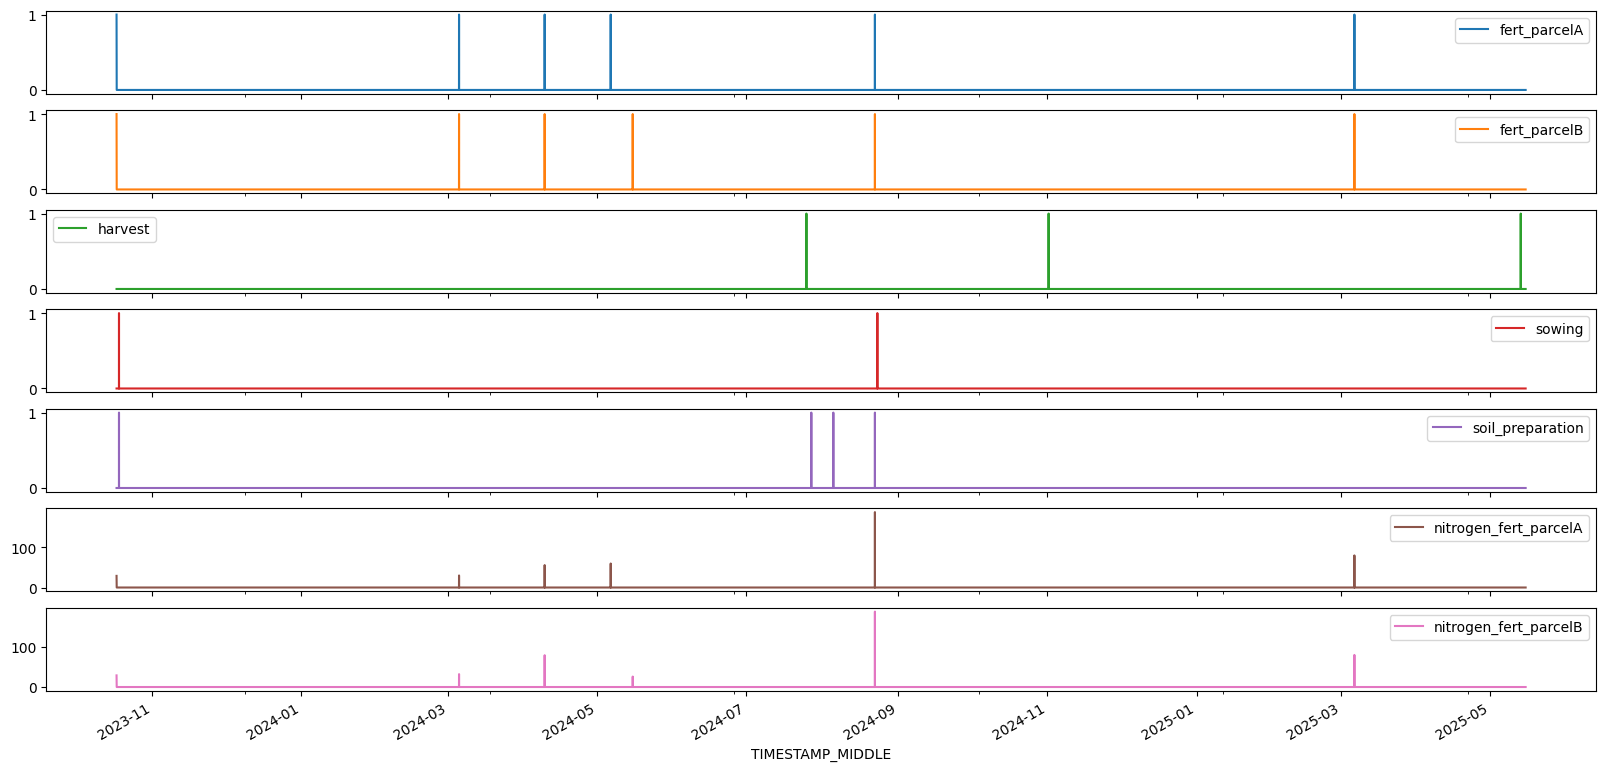

,fert_parcelA,fert_parcelB,harvest,sowing,soil_preparation,nitrogen_fert_parcelA,nitrogen_fert_parcelB,operation,crop_type
TIMESTAMP_MIDDLE,,,,,,,,,
2023-10-17 12:15:00,1,1,0,0,0,29.0,29.0,manure_solid,empty
2023-10-18 12:15:00,0,0,0,1,1,0.0,0.0,field_cultivator+sowing,wwheat
2024-03-05 12:15:00,1,1,0,0,0,30.0,32.1,mineral_NPK+Mg+S,wwheat
2024-03-22 12:15:00,0,0,0,0,0,0.0,0.0,herbicide,wwheat
2024-04-09 12:15:00,1,1,0,0,0,55.9,79.3,mineral_N+Ca,wwheat
2024-05-06 12:15:00,1,0,0,0,0,59.8,0.0,mineral_N,wwheat
2024-05-15 12:15:00,0,1,0,0,0,0.0,26.0,mineral_N+Mg+S,wwheat
2024-07-25 12:15:00,0,0,1,0,0,0.0,0.0,grain_harvest,wwheat
2024-07-27 12:15:00,0,0,0,0,1,0.0,0.0,disc_harrow,empty


In [3]:
# 1) Full 30-min index
start_date = management['TIMESTAMP_MIDDLE'].min()
end_date   = management['TIMESTAMP_MIDDLE'].max()
idx = pd.date_range(start=start_date, end=end_date, freq='30min', name='TIMESTAMP_MIDDLE')

# 2) Initialize mgmt (no merge)
mgmt = pd.DataFrame(index=idx, data={
    'fert_parcelA': 0,
    'fert_parcelB': 0,
    'harvest': 0,
    'sowing': 0,
    'soil_preparation': 0,
    'nitrogen_fert_parcelA': 0.0,
    'nitrogen_fert_parcelB': 0.0,
    'operation': pd.Series(index=idx, dtype='object'),
    'crop_type': pd.Series(index=idx, dtype='object'),
})

# 3) Compute event columns on the raw management table
m = management.copy()
m = m.sort_values('TIMESTAMP_MIDDLE')

condA = (m['management_category'] == 'fertilization') & (m['parcel_a'] == 1)
condB = (m['management_category'] == 'fertilization') & (m['parcel_b'] == 1)

m['fert_parcelA'] = condA.astype(int)
m['fert_parcelB'] = condB.astype(int)
m['harvest']      = m['management_subcategory'].isin(['grain_harvest', 'mowing', 'mulching']).astype(int)
m['sowing']       = (m['management_subcategory'] == 'sowing').astype(int)
m['soil_preparation'] = (m['management_category'] == 'cultivation').astype(int)

m['nitrogen_fert_parcelA'] = np.where(condA, m['n_input_kg_ha'], 0.0)
m['nitrogen_fert_parcelB'] = np.where(condB, m['n_input_kg_ha'], 0.0)

# 4) Aggregate in case there are multiple rows per timestamp
m = m.set_index('TIMESTAMP_MIDDLE')

agg = {
    'fert_parcelA': 'max',
    'fert_parcelB': 'max',
    'harvest': 'max',
    'sowing': 'max',
    'soil_preparation': 'max',
    'nitrogen_fert_parcelA': 'sum',
    'nitrogen_fert_parcelB': 'sum',
    'operation': lambda x: '+'.join(sorted(set(x.dropna()))),
    'crop_type': 'first',
}

g = m.groupby(level=0).agg(agg)

# 5) Assign (no merge/join) into the preallocated mgmt
cols = ['fert_parcelA','fert_parcelB','harvest','sowing','soil_preparation',
        'nitrogen_fert_parcelA','nitrogen_fert_parcelB','operation','crop_type']

for c in cols:
    mgmt.loc[g.index, c] = g[c].values

# (Optional) forward-fill crop_type over the timeline
mgmt['crop_type'] = mgmt['crop_type'].ffill()

# Done — mgmt is indexed by TIMESTAMP_MIDDLE already
# Quick plot
mgmt[['fert_parcelA','fert_parcelB','harvest','sowing','soil_preparation',
      'nitrogen_fert_parcelA','nitrogen_fert_parcelB']].plot(
    subplots=True, figsize=(20,10), x_compat=True
)
plt.show()

mgmt[mgmt['operation'].notna()]

# N FERT RESIDUE CALCULATION

## LINEAR

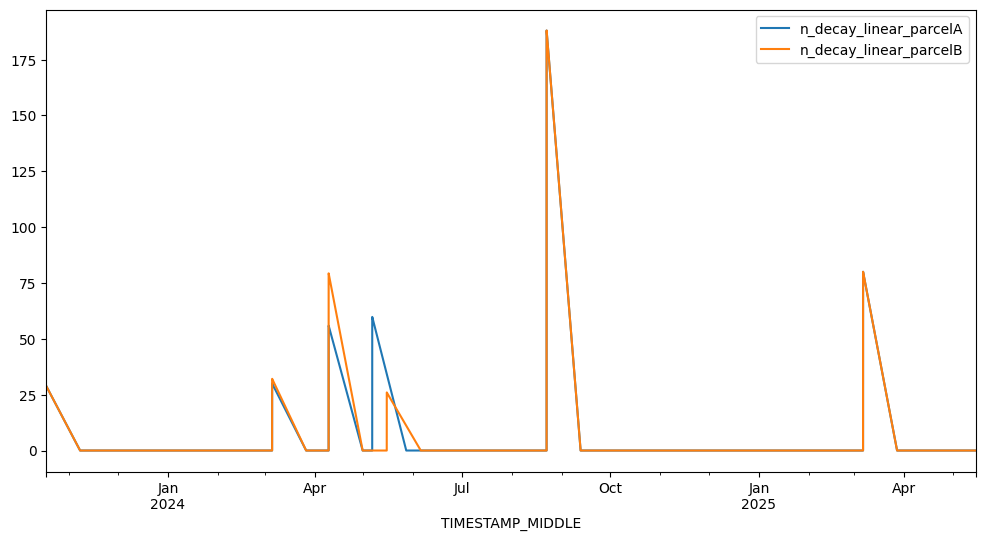

In [4]:
def linear_decay_series(series, duration_steps):
    """
    Build a linear-decay Series from positive pulses in `fert_col`.
    Returns a pandas Series aligned to df.index.
    """
    out = pd.Series(0.0, index=series.index)
    vals = series.fillna(0).to_numpy()
    event_idx = np.flatnonzero(vals > 0)
    n = len(series)

    for i in event_idx:
        fert = vals[i]
        steps = min(duration_steps, n - i)
        dec = fert * (1 - np.arange(steps) / duration_steps)
        dec[dec < 0] = 0.0
        out.iloc[i:i+steps] += dec

    return out

decay_days = 21 # specify how many days to reach zero
mgmt['n_decay_linear_parcelA'] = linear_decay_series(mgmt['nitrogen_fert_parcelA'], duration_steps=48*decay_days)
mgmt['n_decay_linear_parcelB'] = linear_decay_series(mgmt['nitrogen_fert_parcelB'], duration_steps=48*decay_days)

# Plot the new engineered features
mgmt[['n_decay_linear_parcelA', 'n_decay_linear_parcelB']].plot(figsize=(12, 6));

## LOGISTIC

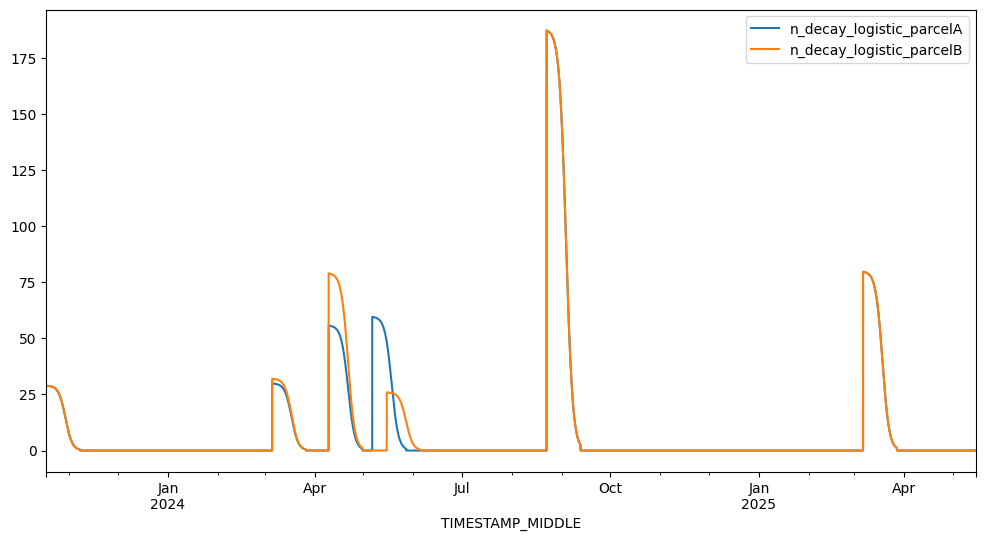

In [5]:
# Function to fill NaNs using a logistic decay with optimized parameters
def logistic_decay_series(series, duration_steps, k, t0):
    """
    Build a logistic-decay Series from positive pulses in `series`.
    Returns a pandas Series aligned to series.index.
    
    Parameters
    ----------
    series : pd.Series
        Input time series with positive pulses (fertilization amounts).
    duration_steps : int
        How long to extend the decay (number of steps).
    k : float
        Logistic steepness parameter.
    t0 : float
        Midpoint of the logistic curve. Defaults to duration_steps/2.
    """
    out = pd.Series(0.0, index=series.index)
    vals = series.fillna(0).to_numpy()
    event_idx = np.flatnonzero(vals > 0)
    n = len(series)
    if t0 is None:
        t0 = duration_steps / 2.0

    for i in event_idx:
        fert = vals[i]
        steps = min(duration_steps, n - i)
        t = np.arange(steps)
        dec = fert / (1 + np.exp(-k * (t - t0)))
        out.iloc[i:i+steps] += dec

    return out

# Visually optimized to my dataset
t0 = 12 * 48
k = - 0.01  # moderate decay rate (decays over ~10 days) 

decay_days = 21 # specify how many days to reach zero

# Apply the logistic decay function to fill NaNs
mgmt['n_decay_logistic_parcelA'] = logistic_decay_series(mgmt['nitrogen_fert_parcelA'], duration_steps=48*decay_days, k=k, t0=t0)
mgmt['n_decay_logistic_parcelB'] = logistic_decay_series(mgmt['nitrogen_fert_parcelB'], duration_steps=48*decay_days, k=k, t0=t0)

# Plot the new engineered features
mgmt[['n_decay_logistic_parcelA', 'n_decay_logistic_parcelB']].plot(figsize=(12, 6));

## EXPONENTIAL

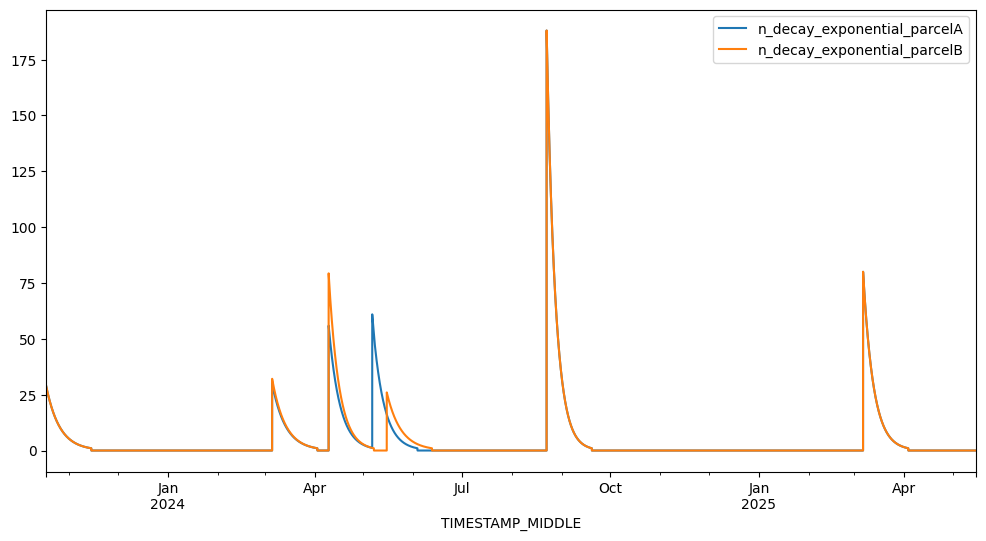

In [6]:
def exponential_decay_series(series, duration_steps, k=None):
    """
    Exponential decay from `fert` toward 0.
    Returns a Series aligned to series.index.
    
    Parameters
    ----------
    series : pd.Series
        Fertilization input pulses.
    duration_steps : int
        Number of steps to apply decay.
    k : float or None
        Decay constant. If None, set so that value drops to ~1/fert at duration_steps.
    """
    out = pd.Series(0.0, index=series.index)
    vals = series.fillna(0).to_numpy()
    event_idx = np.flatnonzero(vals > 0)
    n = len(series)

    for i in event_idx:
        fert = vals[i]
        steps = min(duration_steps, n - i)
        if k is None:
            k_eff = np.log(fert) / duration_steps  # ensures ~1 at end
        else:
            k_eff = k
        t = np.arange(steps)
        dec = fert * np.exp(-k_eff * t)
        out.iloc[i:i+steps] += dec

    return out

decay_days = 28 # specify how many days to reach zero

# Apply the exponential decay function to fill NaNs
mgmt['n_decay_exponential_parcelA'] = exponential_decay_series(mgmt['nitrogen_fert_parcelA'], duration_steps=48*decay_days)
mgmt['n_decay_exponential_parcelB'] = exponential_decay_series(mgmt['nitrogen_fert_parcelB'], duration_steps=48*decay_days)

# Plot the new engineered features
mgmt[['n_decay_exponential_parcelA', 'n_decay_exponential_parcelB']].plot(figsize=(12, 6));

## LOGNORMAL

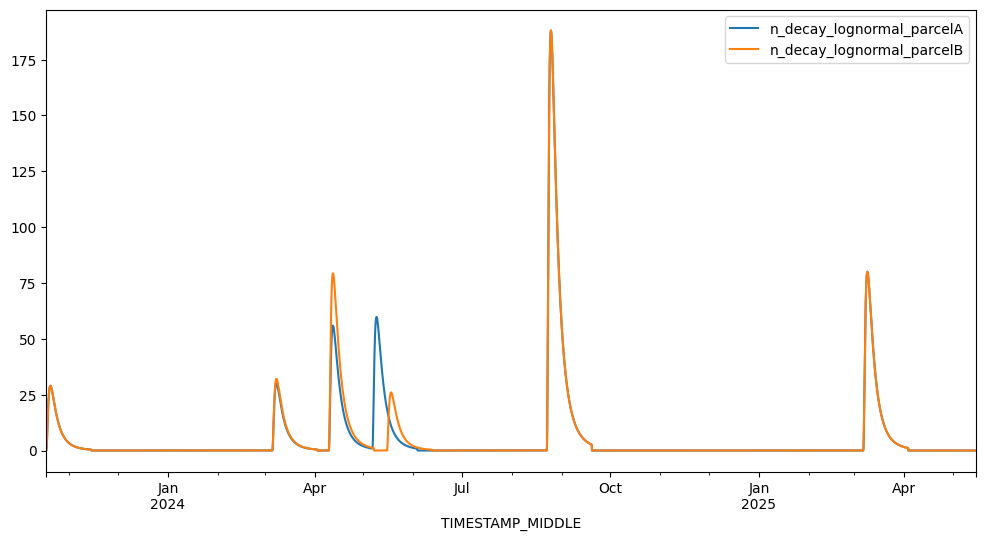

In [7]:
def lognormal_decay_series(series, duration_steps, mu=5.5, sigma=0.5):
    """
    Lognormal-shaped decay from positive pulses in `series`.
    Returns a pandas Series aligned to series.index.
    
    Parameters
    ----------
    series : pd.Series
        Fertilization input pulses.
    duration_steps : int
        Number of steps to apply decay.
    mu : float
        Mean of ln(t) (controls peak location).
    sigma : float
        Std of ln(t) (controls spread).
    """
    out = pd.Series(0.0, index=series.index)
    vals = series.fillna(0).to_numpy()
    event_idx = np.flatnonzero(vals > 0)
    n = len(series)

    # time vector starting from 1 (lognormal undefined at 0)
    t = np.arange(1, duration_steps+1)
    pdf = (1 / (t * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(t) - mu)**2 / (2*sigma**2))
    pdf = pdf / pdf.max()  # normalize to 1 at peak

    for i in event_idx:
        fert = vals[i]
        steps = min(duration_steps, n - i)
        dec = fert * pdf[:steps]
        out.iloc[i:i+steps] += dec

    return out

decay_days = 28 # specify how many days to reach zero

# Define mu and sigma visually
opt_mu = 5.5
opt_sigma = 0.8

# Apply the lognormal decay function to fill NaNs
mgmt['n_decay_lognormal_parcelA'] = lognormal_decay_series(mgmt['nitrogen_fert_parcelA'], duration_steps=48*decay_days, mu=opt_mu, sigma=opt_sigma)
mgmt['n_decay_lognormal_parcelB'] = lognormal_decay_series(mgmt['nitrogen_fert_parcelB'], duration_steps=48*decay_days, mu=opt_mu, sigma=opt_sigma)

# Plot the new engineered features
mgmt[['n_decay_lognormal_parcelA', 'n_decay_lognormal_parcelB']].plot(figsize=(12, 6));

## TIMED

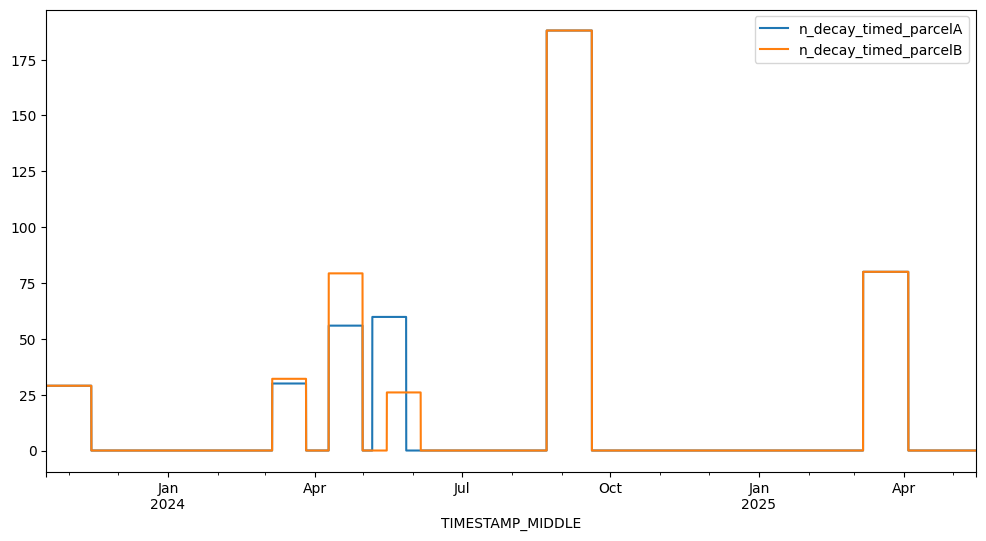

In [8]:
def timed_decay_series(series, fert_type, steps_by_prefix):
    """
    Rolling-sum 'decay' with different windows per fertilization type.

    series : pd.Series         # amounts (e.g., nitrogen_fert_a)
    fert_type : pd.Series      # strings like 'manure...', 'mineral...'
    steps_by_prefix : dict     # e.g., {'manure': 1008, 'mineral': 336}
    default_steps : int|None   # window for unmatched types (optional)
    name : str                 # output name
    """
    out = pd.Series(0.0, index=series.index)
    matched = pd.Series(False, index=series.index)

    ft = fert_type.astype("string")  # safe for .str ops

    for pref, win in steps_by_prefix.items():
        mask = ft.str.contains(pref, na=False)
        matched |= mask
        contrib = series.where(mask, 0.0).rolling(win, min_periods=1).sum()
        out = out.add(contrib.fillna(0.0), fill_value=0.0)
    return out


steps = {'manure': 48*28, 'mineral': 48*21}  # organic ~21d, mineral ~7d

# Apply the timed decay function to fill NaNs
mgmt['n_decay_timed_parcelA'] = timed_decay_series(mgmt['nitrogen_fert_parcelA'], mgmt['operation'], steps)
mgmt['n_decay_timed_parcelB'] = timed_decay_series(mgmt['nitrogen_fert_parcelB'], mgmt['operation'], steps)

# Plot the new engineered features
mgmt[['n_decay_timed_parcelA', 'n_decay_timed_parcelB']].plot(figsize=(12, 6));

# SANITIZE TIMESTAMP

In [9]:
# Remove duplicates, keep first
locs_duplicates = mgmt.index.duplicated(keep='first')
print(f"Found duplicates in index: {locs_duplicates.sum()}")
mgmt = mgmt[~locs_duplicates]

# Remove NaTs
locs_nats = mgmt.index.isnull()
print(f"Found NaTs in index: {locs_nats.sum()}")
mgmt = mgmt[~locs_nats]

# Sort timestamp index
mgmt = mgmt.sort_index(ascending=True)

mgmt

Found duplicates in index: 0
Found NaTs in index: 0


,fert_parcelA,fert_parcelB,harvest,sowing,soil_preparation,nitrogen_fert_parcelA,nitrogen_fert_parcelB,operation,crop_type,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,1,1,0,0,0,29.0,29.0,manure_solid,empty,29.000000,29.000000,28.908905,28.908905,29.000000,29.000000,2.808299e-07,2.808299e-07,29.0,29.0
2023-10-17 12:45:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.971230,28.971230,28.907992,28.907992,28.927434,28.927434,3.727140e-05,3.727140e-05,29.0,29.0
2023-10-17 13:15:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.942460,28.942460,28.907070,28.907070,28.855049,28.855049,4.592764e-04,4.592764e-04,29.0,29.0
2023-10-17 13:45:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.913690,28.913690,28.906140,28.906140,28.782845,28.782845,2.334962e-03,2.334962e-03,29.0,29.0
2023-10-17 14:15:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.884921,28.884921,28.905199,28.905199,28.710822,28.710822,7.540160e-03,7.540160e-03,29.0,29.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15 10:15:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0
2025-05-15 10:45:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0
2025-05-15 11:15:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0


# TIME SINCE VARIABLES
Count time (records) since last occurrence, e.g. time since last precipitation.

Variables for which timesince will be calculated:

In [10]:
_list_timesince_vars = ['soil_preparation', 'harvest', 'sowing', 'fert_parcelA', 'fert_parcelB']

Function to calculate timesince:

In [11]:
def timesince(series, time_resolution, max_duration):
    """
    Compute time since last nonzero event using a group-based approach, considering a user-defined time resolution.

    Args:
    - series (pd.Series): Time series with a DatetimeIndex.
    - time_resolution (float): Time resolution in hours (e.g., 0.5 for 30 min, 1 for hourly, etc.).

    Returns:
    - pd.Series: Series counting time since last event, in days, capped at 30 days.
    """

    # Ensure index is a DatetimeIndex
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DatetimeIndex.")

    # Convert time resolution to fraction of a day
    step_size = time_resolution / 24  # Convert hours to fraction of a day

    # Create a flag: 1 for zeros, 0 for nonzero values
    flag = series.copy()
    flag.loc[series > 0] = 0  # Reset counter when positive values appear
    flag.loc[series == 0] = 1  # Set flag to 1 where series = 0
    flag.loc[series.isnull()] = 1  # Treat NaNs as zeros

    # Identify groups where zero sequences start
    group = (flag != flag.shift()).cumsum()

    # Count steps within each group
    time_since_event = flag * (flag.groupby(group).cumcount() + 1)

    # Convert to days based on given resolution
    days_since_event = np.ceil(time_since_event * step_size).astype(int)

    # **Cap at 30 days** (without keeping previous max values)
    days_since_event = days_since_event.clip(1, max_duration)

    return days_since_event

Calculate timesince variables:

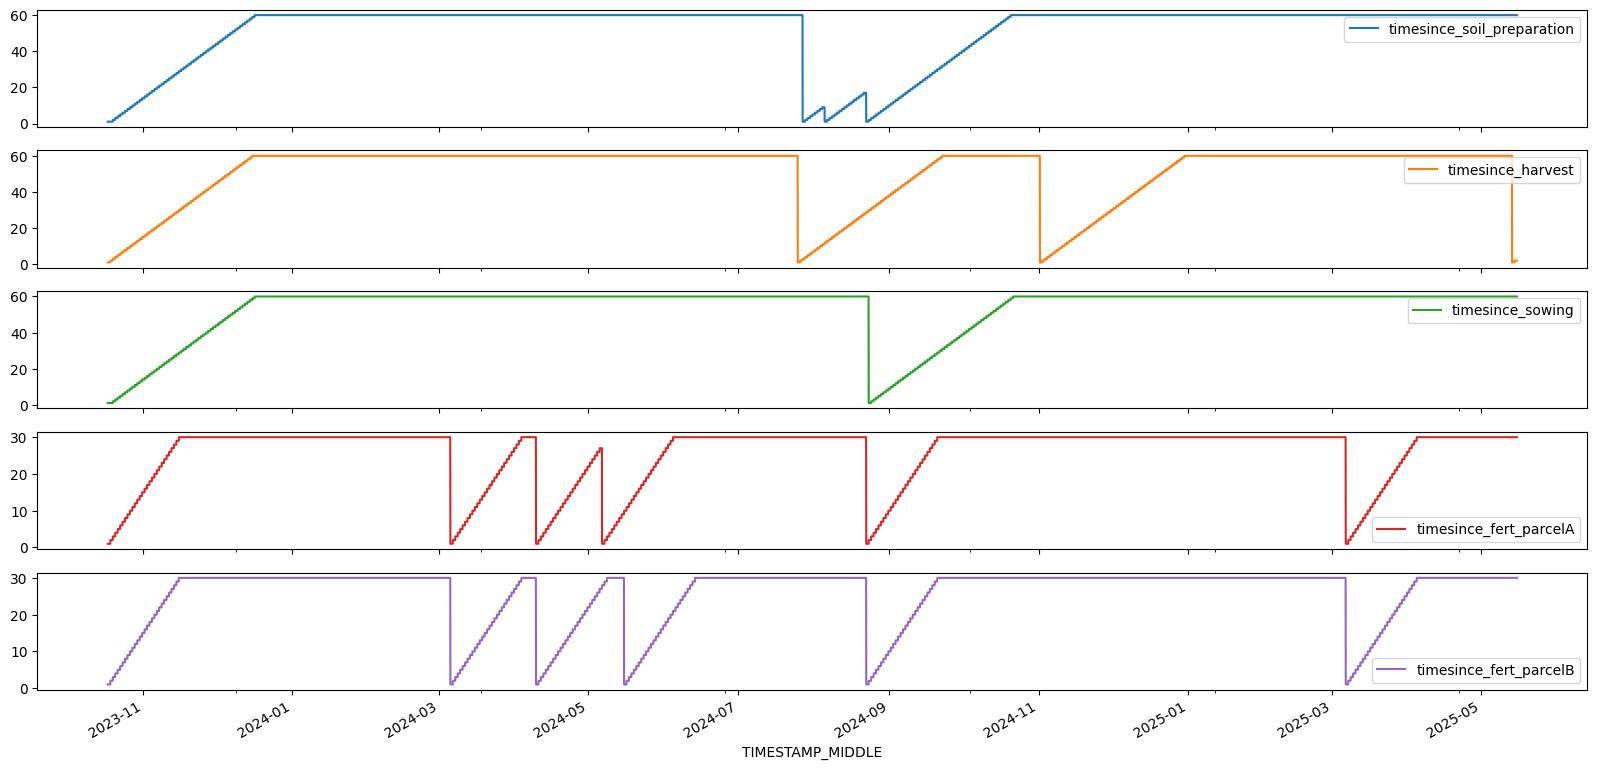

In [12]:
# Copy relevant columns
for v in _list_timesince_vars:      

# Calculate timesince for selected vars
    name_timesince = f'timesince_{v}'
    if 'fert' in v:
        mgmt[name_timesince] = timesince(series=mgmt[v], time_resolution=0.5, max_duration=30).rename(name_timesince)
    else:
        mgmt[name_timesince] = timesince(series=mgmt[v], time_resolution=0.5, max_duration=60).rename(name_timesince)

# Plot the timesince variables
cols = [c for c in mgmt.columns if 'timesince' in c]
mgmt[cols].plot(x_compat=True, subplots=True, figsize=(20,10));

## BINARY TIMED

Variables for which binary timed will be calculated:

In [13]:
_list_binary_timed_vars = ['soil_preparation', 'harvest', 'sowing', 'fert_parcelA', 'fert_parcelB']

Function to calculate the timed variables

In [14]:
def timed_mask(series, time_resolution, max_duration):
    """
    Create a binary variable that is 1 for up to 30 days after a nonzero event, 0 otherwise.

    Args:
    - series (pd.Series): Time series with a DatetimeIndex.
    - time_resolution (float): Time resolution in hours.

    Returns:
    - pd.Series: Binary mask indicating recent event activity (1 if ≤ 30 days since event).
    """
    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("Series index must be a DatetimeIndex.")

    step_size = time_resolution / 24  # fraction of a day

    flag = series.copy()
    flag.loc[series > 0] = 0
    flag.loc[series == 0] = 1
    flag.loc[series.isnull()] = 1

    group = (flag != flag.shift()).cumsum()
    time_since_event = flag * (flag.groupby(group).cumcount() + 1)
    days_since_event = np.ceil(time_since_event * step_size).astype(int)

    return (days_since_event <= max_duration).astype(int)

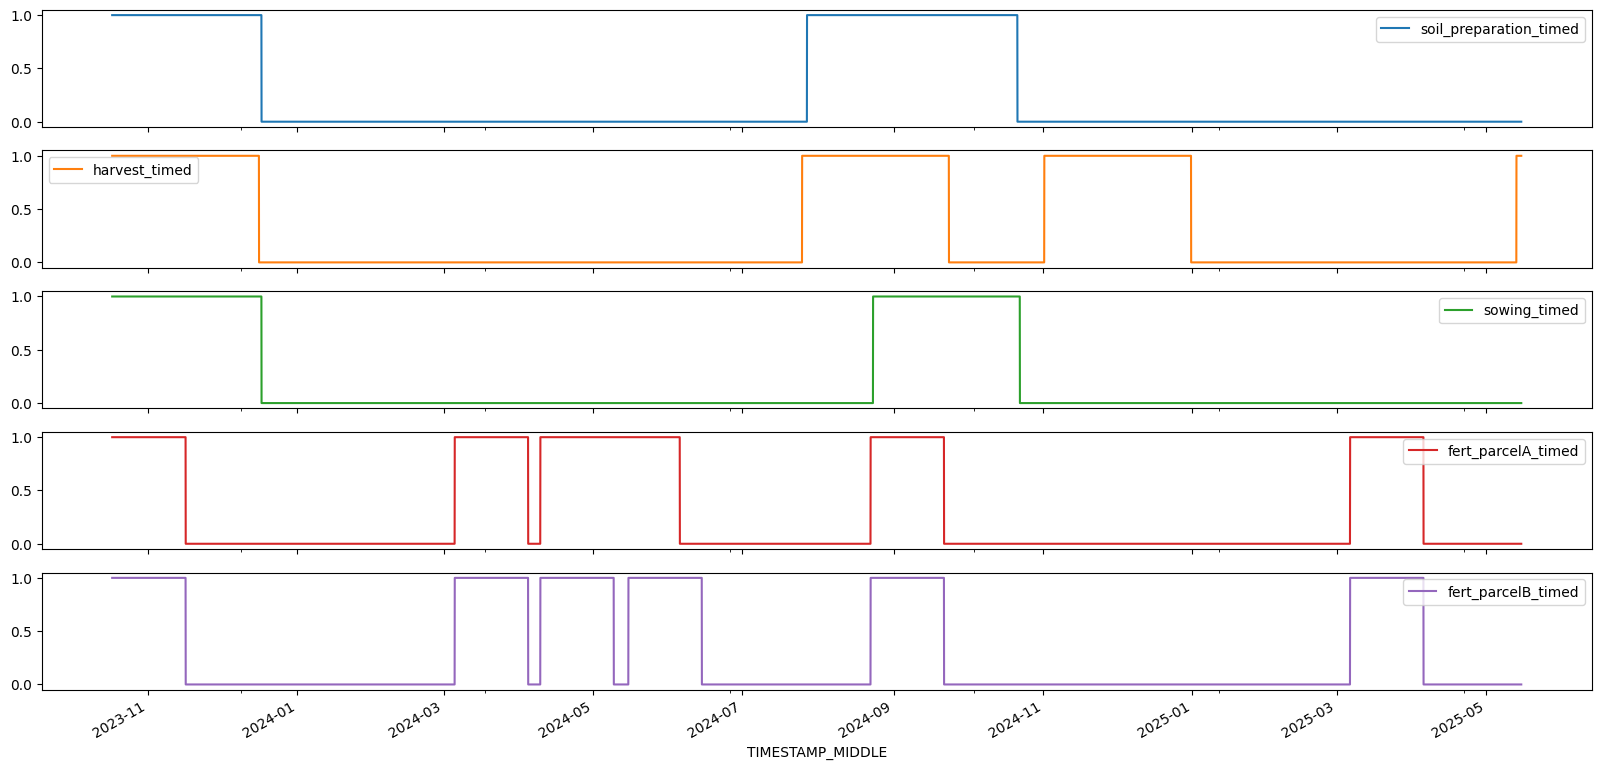

In [15]:
# Copy relevant columns
for v in _list_binary_timed_vars:     

# Calculate timed for selected vars
    name_timed = f'{v}_timed'
    if 'fert' in v:
        mgmt[name_timed] = timed_mask(series=mgmt[v], time_resolution=0.5, max_duration=30).rename(name_timed)
    else:
        mgmt[name_timed] = timed_mask(series=mgmt[v], time_resolution=0.5, max_duration=60).rename(name_timed)

# Plot the timed variables
cols = [c for c in mgmt.columns if 'timed' in c and 'decay' not in c]
mgmt[cols].plot(x_compat=True, subplots=True, figsize=(20,10));

# PLOT ALL VARS

,fert_parcelA,fert_parcelB,harvest,sowing,soil_preparation,nitrogen_fert_parcelA,nitrogen_fert_parcelB,operation,crop_type,n_decay_linear_parcelA,n_decay_linear_parcelB,n_decay_logistic_parcelA,n_decay_logistic_parcelB,n_decay_exponential_parcelA,n_decay_exponential_parcelB,n_decay_lognormal_parcelA,n_decay_lognormal_parcelB,n_decay_timed_parcelA,n_decay_timed_parcelB,timesince_soil_preparation,timesince_harvest,timesince_sowing,timesince_fert_parcelA,timesince_fert_parcelB,soil_preparation_timed,harvest_timed,sowing_timed,fert_parcelA_timed,fert_parcelB_timed
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 12:15:00,1,1,0,0,0,29.0,29.0,manure_solid,empty,29.000000,29.000000,28.908905,28.908905,29.000000,29.000000,2.808299e-07,2.808299e-07,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 12:45:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.971230,28.971230,28.907992,28.907992,28.927434,28.927434,3.727140e-05,3.727140e-05,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 13:15:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.942460,28.942460,28.907070,28.907070,28.855049,28.855049,4.592764e-04,4.592764e-04,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 13:45:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.913690,28.913690,28.906140,28.906140,28.782845,28.782845,2.334962e-03,2.334962e-03,29.0,29.0,1,1,1,1,1,1,1,1,1,1
2023-10-17 14:15:00,0,0,0,0,0,0.0,0.0,NaN,empty,28.884921,28.884921,28.905199,28.905199,28.710822,28.710822,7.540160e-03,7.540160e-03,29.0,29.0,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-15 10:15:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,2,60,30,30,0,1,0,0,0
2025-05-15 10:45:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,2,60,30,30,0,1,0,0,0
2025-05-15 11:15:00,0,0,0,0,0,0.0,0.0,NaN,grassland,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,60,2,60,30,30,0,1,0,0,0


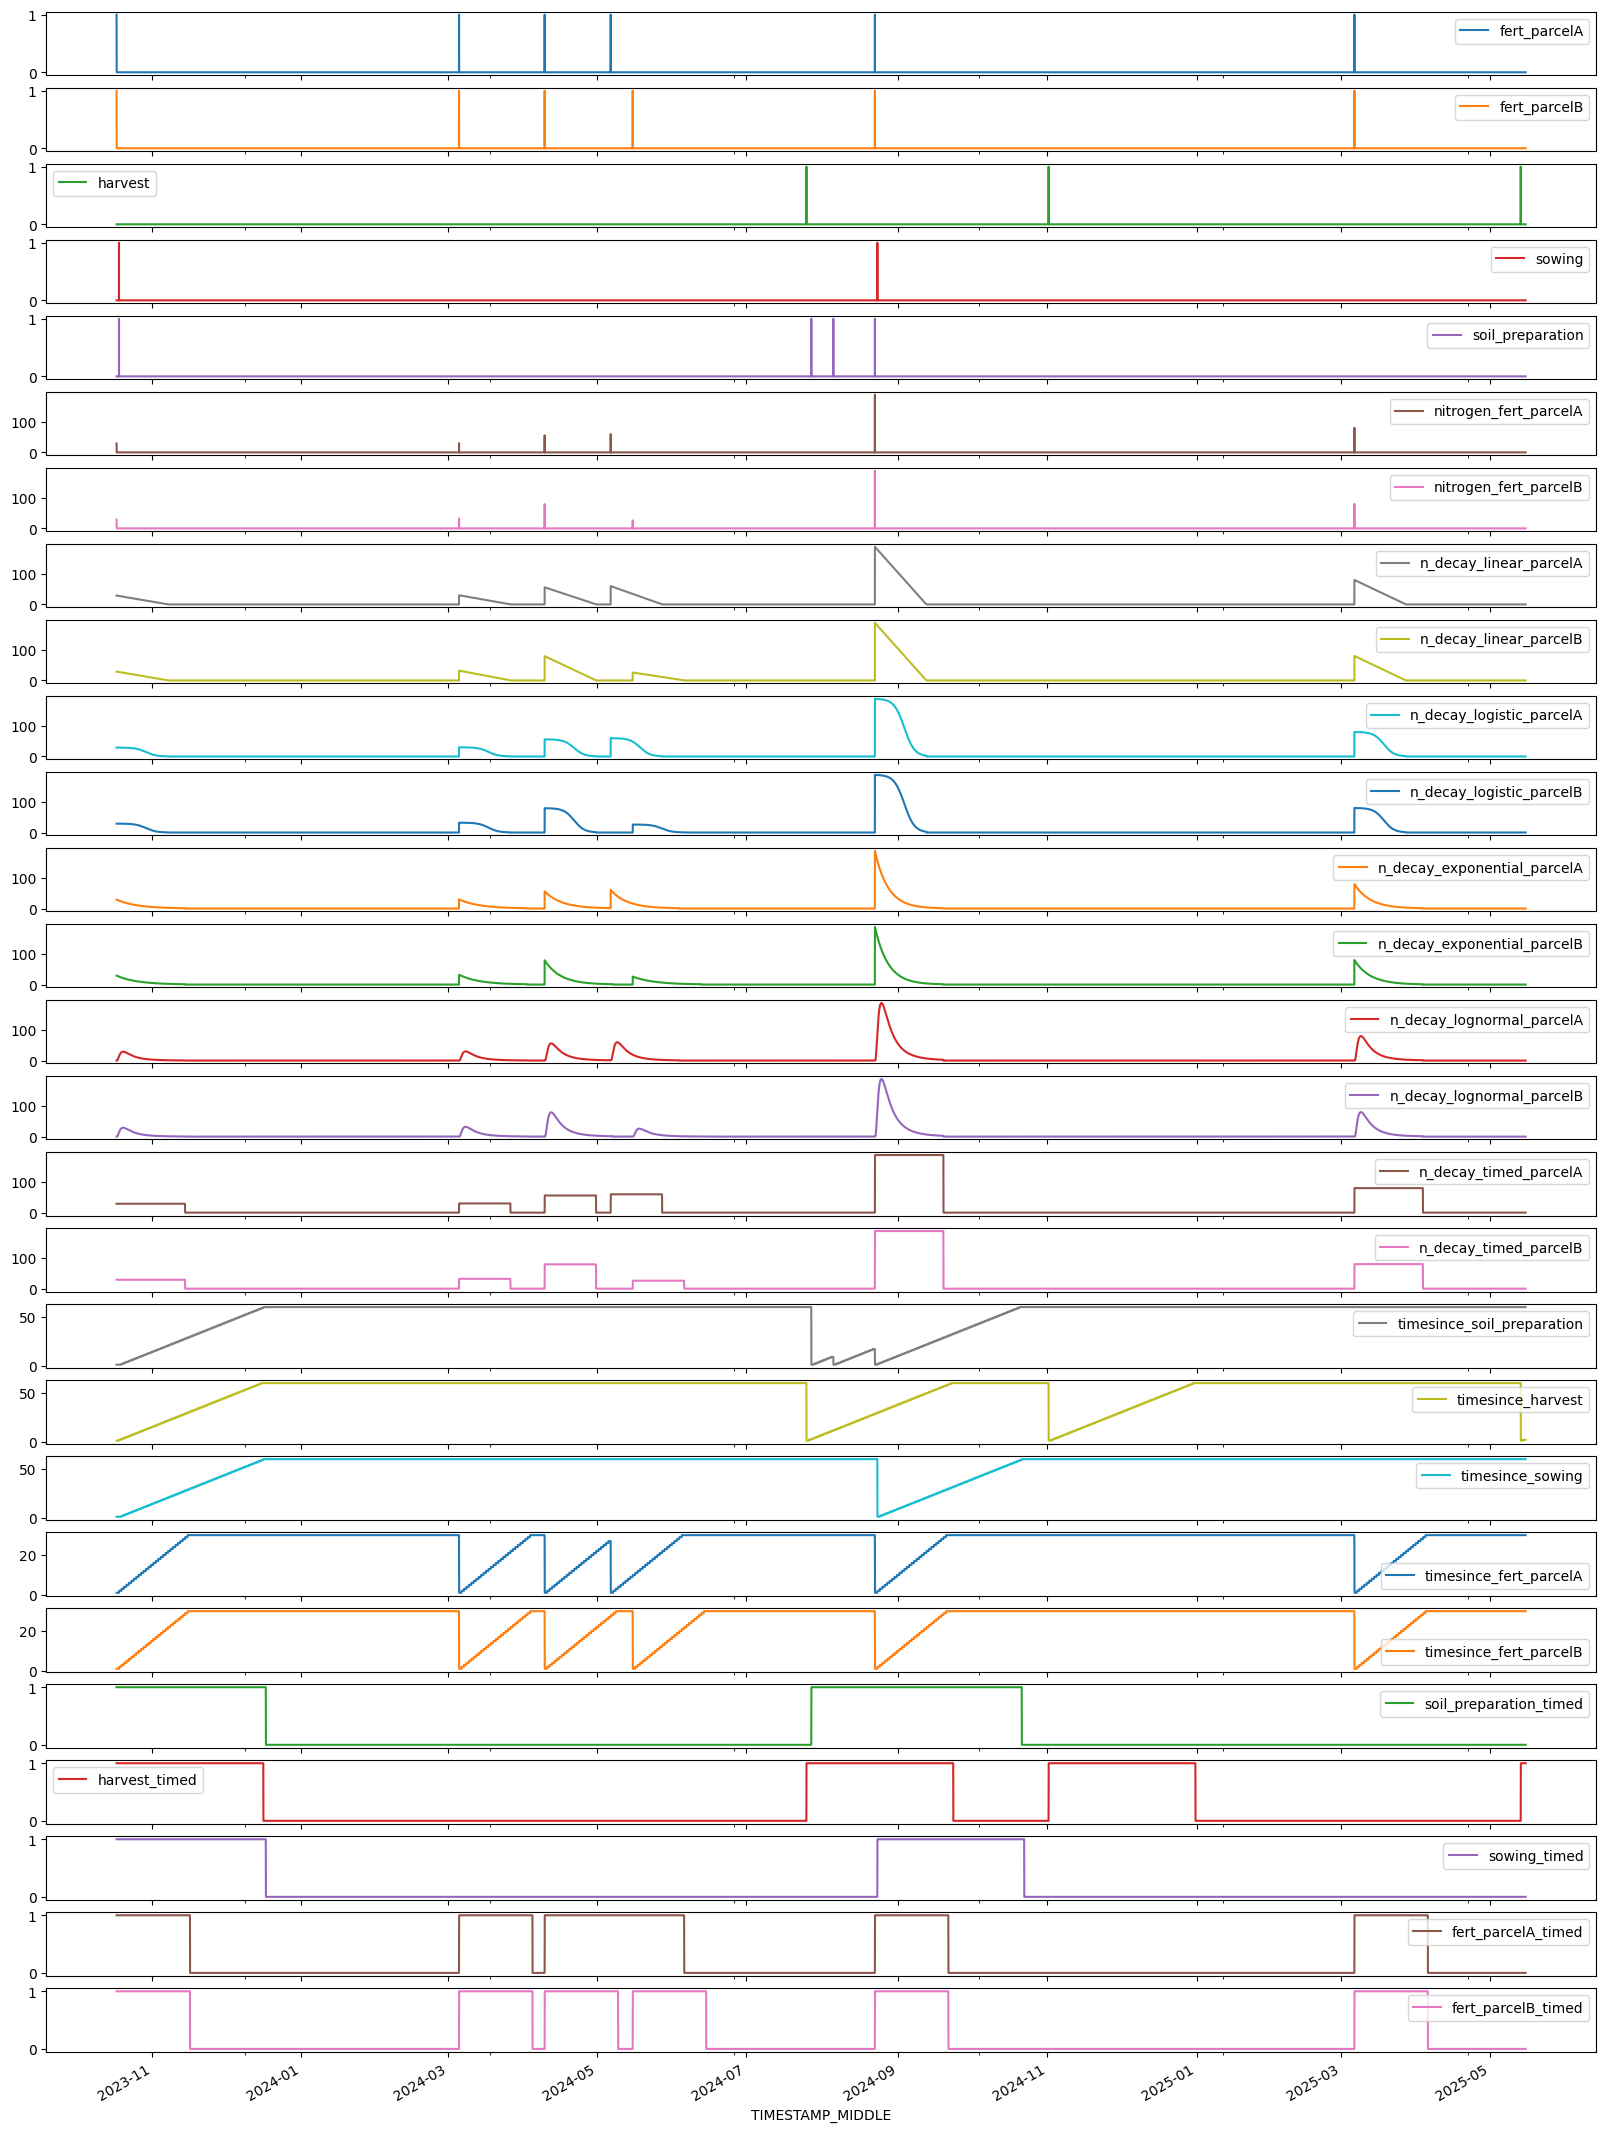

In [16]:
mgmt.plot(subplots=True, figsize=(20, 30), x_compat=True);
mgmt

# EXPORT

In [17]:
filename = "21.1_mgmt_full_timestamp"
mgmt.to_csv(f'{filename}.csv', index=True)
save_parquet(data=mgmt, filename=filename)

Saved file 21.1_mgmt_full_timestamp.parquet (0.291 seconds).


'21.1_mgmt_full_timestamp.parquet'

# End of notebook

In [18]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-09-25 18:54:08
